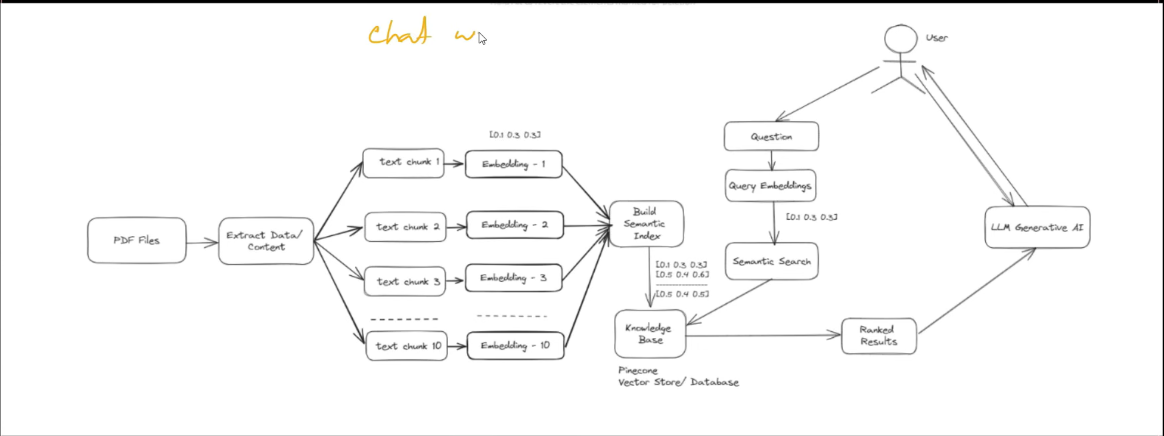

In [82]:
### 1. Install Required Libraries
!pip install -q llama-index llama-index-readers-file llama-index-llms-gemini pymupdf

In [83]:
### 2. Import Modules and Setup Environment
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex
from llama_index.llms.gemini import Gemini
from llama_index.core import ServiceContext
from llama_index.core import StorageContext, load_index_from_storage
import os

#### **LOAD THE DATA**

In [84]:
### 3. Create Data Directory
!mkdir -p data

In [85]:
### 4. Load and Parse PDF Document
from llama_index.readers.file import PyMuPDFReader
from pathlib import Path

loader = PyMuPDFReader()
documents = loader.load_data(file_path=Path("data/TGR.pdf"))
print(f"Successfully parsed {len(documents)} pages of text.")

Successfully parsed 253 pages of text.


In [8]:
documents

[Document(id_='dc66d97d-0319-48c2-b6f1-091c0fe64839', embedding=None, metadata={'file_path': 'data/TGR.pdf', 'file_name': 'TGR.pdf', 'file_type': 'application/pdf', 'file_size': 1297961, 'creation_date': '2026-09-18', 'last_modified_date': '2026-09-18'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={}, metadata_template='{key}: {value}', metadata_separator='\n', text_resource=MediaResource(embeddings=None, data=None, text='%PDF-1.4\n%äüöß\n2 0 obj\n<</Length 3 0 R/Filter/FlateDecode>>\nstream\ndӞ\ta$V{H\x99f\x07Mpѐ\x13\x10Wqpb\x1e\x04po\x1ce\x01h~lc\n{|+y\x1f*wc`\x03\x1f?\x13rS\x1fԀfx\x12\\Vg\x08EC}\x0bdx)\x02\x01왃~9a&\x15N\x15u\x18ʯ[W`.?:C\x1d\x06"\x16ȚgNv./"\x0c\x10.4ajE\x04\x05,BPPRw\x17+\t|cf32Z\x0cg^?N%ќq3\x1aA+\x12\'ZvK}\x00j.?+\x12`kR\x16̄\'yY\x1amos\x07

#### **SPLIT THE DATA INTO SMALL CHUNKS**

In [89]:
os.environ['GEMINI_API_KEY'] = "API_KEY"

In [90]:
### 6. Configure LLM and Settings
import os
from llama_index.llms.gemini import Gemini
from llama_index.core import Settings

# Retrieve the API key and configure the LlamaIndex Gemini model
api_key = os.environ.get('GEMINI_API_KEY')
llm = Gemini(model="models/gemini-3.6-flash", api_key=api_key)

# Configure LlamaIndex to use this model and chunk settings by default
Settings.llm = llm
Settings.chunk_size = 800
Settings.chunk_overlap = 20

/tmp/ipykernel_1613/2763926086.py:8: DeprecationWarning: Call to deprecated class Gemini. (Should use `llama-index-llms-google-genai` instead, using Google's latest unified SDK. See: https://docs.llamaindex.ai/en/stable/examples/llm/google_genai/This package will no longer be supported after version 0.6.2) -- Deprecated since version 0.6.2.
  llm = Gemini(model="models/gemini-3.6-flash", api_key=api_key)


In [88]:
### 7. Install Embedding Model Library
!pip install -q llama-index-embeddings-huggingface

In [91]:
### 8. Configure Embedding Model
from llama_index.embeddings.huggingface import HuggingFaceEmbedding

Settings.embed_model = HuggingFaceEmbedding(
    model_name="BAAI/bge-small-en-v1.5"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [92]:
### 9. Build Vector Index
vector_stores = VectorStoreIndex.from_documents(documents)

In [56]:
vector_stores

In [93]:
### 10. Persist Index to Disk
vector_stores.storage_context.persist()

In [94]:
### 11. Load Index from Storage
storage_context = StorageContext.from_defaults(persist_dir="./storage")
index = load_index_from_storage(storage_context)

In [95]:
### 12. Run Retrieval Query
query_engine = vector_stores.as_query_engine()
response = query_engine.query("How do one think and grow rich")
print(response.response)

To think and grow rich, one must adopt a specific state of mind characterized by a definiteness of purpose, rather than relying strictly on long and hard physical labor. Riches begin within the mind and are realized by generating and executing sound ideas, plans, and purposes.

To achieve this state of mind and attract wealth:

* **Develop Definiteness of Purpose:** Establish a clear objective and remain open to practical ideas and plans that spring into the mind.
* **Master and Apply Success Principles:** Seek out, master, and consistently follow the rules and instructions that have enabled others to achieve success. Applying these principles helps turn everyday efforts and opportunities into valuable assets.
* **Practice the Master Mind Principle:** Form a study group or club with friendly, harmonious people who meet regularly (such as weekly). Analyze and freely discuss core principles, exchange ideas, and take notes on new insights inspired by the collective discussion.
* **Engage 

<br>
<br>

#### **Sample Test**

In [96]:
### 13. Consolidated Pipeline Verification
# Load, Index, and Query in one flow
from llama_index.readers.file import PyMuPDFReader
from llama_index.core import VectorStoreIndex

loader = PyMuPDFReader()
documents = loader.load(file_path="data/TGR.pdf")

print("--- Sample Text Extraction ---")
print(documents[0].text[:500])

vector_stores = VectorStoreIndex.from_documents(documents)
query_engine = vector_stores.as_query_engine()
response = query_engine.query("What is mentioned in the available information?")
print("--- LLM Response ---")
print(response.response)

--- Sample Text Extraction ---
  THINK & GROW RICH   
Free Digital Download PDF eBook Edition 
Re-published by: 
  www.think-and-grow-rich-ebook.com  
i

--- LLM Response ---
The provided information includes a Table of Contents for *Think & Grow Rich*, detailing various introductory sections and chapter topics structured as steps toward riches, including Desire, Faith, Auto-Suggestion, Specialized Knowledge, Imagination, Organized Planning, and Decision. 

Additionally, it outlines details regarding a professional service where an individual uses a staff of typists, artists, and writers to dramatize case histories and create plans that help clients market their personal services for higher pay, particularly in executive or managerial positions. This service charges a percentage of the increased pay earned by the client and ensures employers get full value. It emphasizes that while specialized knowledge is widely available, imagination is the essential quality required to combine s

In [97]:
### 14. Visualize Source Citations
from IPython.display import Markdown, display

markdown_text = "### 📚 Source Documents\n\n"
for i, source in enumerate(response.source_nodes, 1):
    node_id = source.node.node_id
    text = source.node.get_content().replace('\n', ' ').strip()
    score = round(source.score, 3) if source.score else "N/A"
    markdown_text += f"**{i}. Node ID:** `{node_id}` (Similarity Score: {score})\n"
    markdown_text += f"> *\"{text[:300]}...\"*\n\n"
    markdown_text += "---\n\n"

display(Markdown(markdown_text))

### 📚 Source Documents

**1. Node ID:** `c91f8a18-d438-4a26-87f0-7432eff48dde` (Similarity Score: 0.653)
> *"  THINK & GROW RICH    Table Of Contents WHAT DO YOU WANT MOST?.............................................................................................4 PUBLISHER'S PREFACE...........................................................................................................8 AUTHOR'S PRE..."*

---

**2. Node ID:** `5146376b-e572-42f2-b5b0-175c010c62ea` (Similarity Score: 0.63)
> *"  THINK & GROW RICH    preparing similar plans for others who desire to market their personal services  for more money. She has a staff of expert typists, artists, and writers who have  the ability to dramatize the case history so effectively that one's personal services  can be marketed for much ..."*

---

